# California Wildfire Agent: Ten Reproducible Questions

This notebook downloads the California wildfire agent support bundle from the I-GUIDE Platform, verifies its checksum, loads the repository's `wildfire_refactor` package, and executes ten deterministic questions with large-language-model access disabled.

The bundle contains county aggregates, California geometries, trained models, preprocessing state, and offline fixtures.

> Model probabilities are analytical research estimates. They are not operational fire warnings, emergency guidance, or qualitative risk categories.


In [1]:
# Install only packages missing from the active kernel.
from importlib.util import find_spec
import subprocess
import sys

REQUIRED_PACKAGES = {
    "numpy": "numpy>=1.26",
    "pandas": "pandas>=2.1",
    "plotly": "plotly>=6.0",
    "dateparser": "dateparser>=1.2",
    "h3": "h3>=4,<5",
    "joblib": "joblib>=1.3",
    "xgboost": "xgboost>=3.0",
    "sklearn": "scikit-learn>=1.5",
    "requests": "requests>=2.31",
    "pydantic": "pydantic>=2.8",
    "dotenv": "python-dotenv>=1.0",
}

missing = [
    package
    for import_name, package in REQUIRED_PACKAGES.items()
    if find_spec(import_name) is None
]

if missing:
    print("Installing missing packages:", ", ".join(missing))
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "--quiet", *missing]
    )
else:
    print("All required packages are already available.")


All required packages are already available.


In [2]:
# Download, verify, and safely extract Dataset B.
from pathlib import Path
from urllib.request import urlretrieve
import hashlib
import os
import zipfile

AGENT_BUNDLE_URL = (
    "https://storage.i-guide.io/datasets/"
    "b09a55f3-3e79-4f73-ae4d-b6c34fd10647/"
    "iguide_california_wildfire_agent_bundle.zip"
)

WORK_DIR = Path.cwd() / "iguide_wildfire_agent_workspace"
DOWNLOAD_DIR = WORK_DIR / "downloads"
EXTRACT_DIR = WORK_DIR / "agent_bundle"
ZIP_PATH = DOWNLOAD_DIR / "iguide_california_wildfire_agent_bundle.zip"

DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()

def safe_extract_zip(zip_path: Path, destination: Path) -> None:
    destination = destination.resolve()
    with zipfile.ZipFile(zip_path) as archive:
        for member in archive.infolist():
            target = (destination / member.filename).resolve()
            if destination != target and destination not in target.parents:
                raise ValueError(f"Unsafe archive member: {member.filename}")
        archive.extractall(destination)

marker_files = list(EXTRACT_DIR.rglob("preprocessor_state.json"))
if not marker_files:
    if not ZIP_PATH.exists():
        print("Downloading Dataset B from I-GUIDE...")
        urlretrieve(AGENT_BUNDLE_URL, ZIP_PATH)

    print("Archive checksum verified. Extracting Dataset B...")
    safe_extract_zip(ZIP_PATH, EXTRACT_DIR)

def require_one(filename: str) -> Path:
    matches = list(EXTRACT_DIR.rglob(filename))
    if len(matches) != 1:
        raise FileNotFoundError(
            f"Expected exactly one {filename}; found {len(matches)}."
        )
    return matches[0]

RF_MODEL_PATH = require_one("random_forest_model.joblib")
XGB_MODEL_PATH = require_one("xgboost_model.json")
PREPROCESSOR_PATH = require_one("preprocessor_state.json")

county_parquet_matches = list(
    EXTRACT_DIR.rglob("county_monthly_averages.parquet")
)
COUNTY_PARQUET_PATH = (
    county_parquet_matches[0] if county_parquet_matches else None
)

county_csv_dirs = []
directories = [EXTRACT_DIR] + [
    path for path in EXTRACT_DIR.rglob("*") if path.is_dir()
]
for directory in directories:
    csv_count = len(list(directory.glob("*.csv")))
    if csv_count >= 50:
        county_csv_dirs.append((csv_count, directory))
COUNTY_CSV_DIR = max(county_csv_dirs, default=(0, None))[1]

question_matches = list(EXTRACT_DIR.rglob("QUESTIONS.md"))
QUESTIONS_PATH = question_matches[0] if question_matches else None

geojson_matches = list(EXTRACT_DIR.rglob("ca_counties.geojson"))
COUNTY_GEOJSON_PATH = geojson_matches[0] if geojson_matches else None

fixture_dirs = [
    path for path in EXTRACT_DIR.rglob("offline_fixtures")
    if path.is_dir()
]
FIXTURES_DIR = fixture_dirs[0] if fixture_dirs else None

if COUNTY_CSV_DIR is None and COUNTY_PARQUET_PATH is None:
    raise FileNotFoundError("No county aggregate data found in Dataset B.")
if QUESTIONS_PATH is None:
    raise FileNotFoundError("QUESTIONS.md was not found in Dataset B.")

os.environ.update(
    {
        "WILDFIRE_BUNDLE_DIR": str(EXTRACT_DIR.resolve()),
        "WILDFIRE_RF_MODEL_PATH": str(RF_MODEL_PATH.resolve()),
        "WILDFIRE_XGB_MODEL_PATH": str(XGB_MODEL_PATH.resolve()),
        "WILDFIRE_PREPROCESSOR_PATH": str(PREPROCESSOR_PATH.resolve()),
        "WILDFIRE_OFFLINE": "1",
        "WILDFIRE_USE_LLM": "0",
    }
)
if COUNTY_CSV_DIR is not None:
    os.environ["WILDFIRE_COUNTY_STORE_DIR"] = str(
        COUNTY_CSV_DIR.resolve()
    )
if COUNTY_PARQUET_PATH is not None:
    os.environ["WILDFIRE_COUNTY_PARQUET_PATH"] = str(
        COUNTY_PARQUET_PATH.resolve()
    )
if COUNTY_GEOJSON_PATH is not None:
    os.environ["WILDFIRE_COUNTY_GEOJSON_PATH"] = str(
        COUNTY_GEOJSON_PATH.resolve()
    )
if FIXTURES_DIR is not None:
    os.environ["WILDFIRE_FIXTURES_DIR"] = str(FIXTURES_DIR.resolve())

print("Agent bundle is ready.")
print("Random Forest:", RF_MODEL_PATH)
print("XGBoost:", XGB_MODEL_PATH)
print("Preprocessor:", PREPROCESSOR_PATH)
print("County CSV directory:", COUNTY_CSV_DIR)
print("County Parquet:", COUNTY_PARQUET_PATH)


Agent bundle is ready.
Random Forest: /Users/alikhosravikazazi/Downloads/Files/IGUIDE_WILDFIRE_PUBLICATION/repository/wildfire-summer-school/notebooks/iguide_wildfire_agent_workspace/agent_bundle/models/random_forest_model.joblib
XGBoost: /Users/alikhosravikazazi/Downloads/Files/IGUIDE_WILDFIRE_PUBLICATION/repository/wildfire-summer-school/notebooks/iguide_wildfire_agent_workspace/agent_bundle/models/xgboost_model.json
Preprocessor: /Users/alikhosravikazazi/Downloads/Files/IGUIDE_WILDFIRE_PUBLICATION/repository/wildfire-summer-school/notebooks/iguide_wildfire_agent_workspace/agent_bundle/models/preprocessor_state.json
County CSV directory: /Users/alikhosravikazazi/Downloads/Files/IGUIDE_WILDFIRE_PUBLICATION/repository/wildfire-summer-school/notebooks/iguide_wildfire_agent_workspace/agent_bundle/data/County_Monthly_Averages
County Parquet: /Users/alikhosravikazazi/Downloads/Files/IGUIDE_WILDFIRE_PUBLICATION/repository/wildfire-summer-school/notebooks/iguide_wildfire_agent_workspace/agen

In [3]:
from __future__ import annotations

import copy
import html
import inspect
import re
import sys
import time
import warnings
from pathlib import Path

import pandas as pd
import plotly.express as px
import plotly.io as pio
from IPython.display import HTML, display

# Locate src/wildfire_refactor whether the kernel starts from the repository
# root or from its notebooks directory.
search_bases = [Path.cwd(), *Path.cwd().parents]
src_candidates = []
for base in search_bases:
    src_candidates.extend(
        [
            base / "src",
            base / "wildfire-summer-school" / "src",
            base / "repository" / "wildfire-summer-school" / "src",
        ]
    )

SRC_PATH = next(
    (
        candidate
        for candidate in src_candidates
        if (candidate / "wildfire_refactor").is_dir()
    ),
    None,
)
if SRC_PATH is None:
    raise FileNotFoundError(
        "Could not locate src/wildfire_refactor. "
        "Run this notebook from the published wildfire-summer-school repository."
    )

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from wildfire_refactor import WildfireAgent
from wildfire_refactor.data.county_store import CountyAggregateStore

warnings.filterwarnings("ignore", category=UserWarning)
pio.renderers.default = "png"
pd.set_option("display.max_columns", 20)
pd.set_option("display.max_colwidth", 80)

question_text = QUESTIONS_PATH.read_text(encoding="utf-8")
questions = re.findall(r"^\d+\. `(.+)`$", question_text, flags=re.MULTILINE)
assert len(questions) == 10, f"Expected 10 questions, found {len(questions)}"

if COUNTY_CSV_DIR is None:
    raise RuntimeError(
        "The current CountyAggregateStore requires the 58 county CSV files, "
        "but no county CSV directory was found in Dataset B."
    )
store = CountyAggregateStore(COUNTY_CSV_DIR)

# Pass only constructor arguments supported by the repository version.
constructor_parameters = inspect.signature(WildfireAgent).parameters
agent_kwargs = {"store": store, "use_llm": False}

optional_constructor_values = {
    "offline": True,
    "bundle_dir": EXTRACT_DIR,
    "data_dir": EXTRACT_DIR,
    "model_dir": RF_MODEL_PATH.parent,
    "models_dir": RF_MODEL_PATH.parent,
    "rf_model_path": RF_MODEL_PATH,
    "random_forest_model_path": RF_MODEL_PATH,
    "xgb_model_path": XGB_MODEL_PATH,
    "xgboost_model_path": XGB_MODEL_PATH,
    "preprocessor_path": PREPROCESSOR_PATH,
    "preprocessor_state_path": PREPROCESSOR_PATH,
    "county_geojson_path": COUNTY_GEOJSON_PATH,
    "fixtures_dir": FIXTURES_DIR,
}
for parameter, value in optional_constructor_values.items():
    if parameter in constructor_parameters and value is not None:
        agent_kwargs[parameter] = value

agent = WildfireAgent(**agent_kwargs)
results = {}

display(HTML("""
<style>
.wf-question {border-left: 5px solid #c2410c; background: #fff7ed; padding: 14px 18px; margin: 20px 0 12px;}
.wf-question small {color: #9a3412; font-weight: 700; text-transform: uppercase;}
.wf-message {font-size: 1.05rem; line-height: 1.65; padding: 14px 16px; border: 1px solid #d1d5db; border-radius: 6px; background: #ffffff;}
.wf-warning {margin: 10px 0; padding: 11px 14px; border-left: 4px solid #d97706; background: #fffbeb;}
.wf-meta {display: flex; flex-wrap: wrap; gap: 7px; margin: 10px 0 16px;}
.wf-chip {background: #e5e7eb; border-radius: 999px; padding: 4px 9px; font-size: 0.82rem;}
.wf-section {color: #374151; margin: 18px 0 8px; font-size: 1rem; font-weight: 700;}
.dataframe {font-size: 0.9rem !important;}
</style>
"""))

print(
    f"Loaded {len(questions)} questions and initialized WildfireAgent "
    f"with deterministic settings: {agent_kwargs}"
)


Loaded 10 questions and initialized WildfireAgent with deterministic settings: {'store': <wildfire_refactor.data.county_store.CountyAggregateStore object at 0x11936e240>, 'use_llm': False}


In [4]:
from IPython.display import Image
def _styled_frame(frame: pd.DataFrame):
    numeric = list(frame.select_dtypes(include="number").columns)
    styler = frame.style.format(precision=4, na_rep="-").hide(axis="index")
    if "probability" in numeric and len(frame) > 1:
        styler = styler.background_gradient(cmap="YlOrRd", subset=["probability"])
    return styler.set_table_styles([
        {"selector": "th", "props": [("background", "#1f2937"), ("color", "white"), ("padding", "8px")]},
        {"selector": "td", "props": [("padding", "7px 9px"), ("border-bottom", "1px solid #e5e7eb")]},
    ])


def _statistics_frame(statistics: dict) -> pd.DataFrame:
    if any(isinstance(value, dict) for value in statistics.values()):
        rows = []
        for metric, values in statistics.items():
            rows.append({"metric": metric, **(values if isinstance(values, dict) else {"value": values})})
        return pd.DataFrame(rows)
    return pd.DataFrame([statistics])


def _coordinate_pairs(coordinates):
    if coordinates and isinstance(coordinates[0], (int, float)):
        yield coordinates
        return
    for item in coordinates or []:
        yield from _coordinate_pairs(item)


def _show_chart(chart: dict):
    frame = pd.DataFrame(chart.get("data", []))
    if frame.empty:
        return
    common = dict(data_frame=frame, x=chart["x"], y=chart["y"], template="plotly_white")
    if chart.get("type") == "bar":
        figure = px.bar(**common, color=chart["y"], color_continuous_scale="YlOrRd")
    else:
        figure = px.line(**common, markers=True)
    figure.update_layout(height=430, margin=dict(l=30, r=20, t=30, b=30), coloraxis_showscale=False)
    display(Image(figure.to_image(format="png", width=850, height=430)))


def _show_map(visualization: dict):
    geojson = copy.deepcopy(visualization.get("geojson", {}))
    features = geojson.get("features", [])
    if not features:
        return
    mode = visualization.get("mode", "points")
    if features[0].get("geometry", {}).get("type") == "Point":
        records = [{**feature.get("properties", {}), "longitude": feature["geometry"]["coordinates"][0], "latitude": feature["geometry"]["coordinates"][1]} for feature in features]
        frame = pd.DataFrame(records)
        lat_span = frame["latitude"].max() - frame["latitude"].min()
        lon_span = frame["longitude"].max() - frame["longitude"].min()
        is_statewide = len(frame) > 100 or lat_span > 4.0 or lon_span > 4.0
        center_lat = float(frame["latitude"].mean())
        center_lon = float(frame["longitude"].mean())
        zoom_level = 4.5 if is_statewide else 7.5
        if mode == "heat" and len(frame) > 2:
            figure = px.density_map(frame, lat="latitude", lon="longitude", z="probability", radius=18 if is_statewide else 24, center=dict(lat=center_lat, lon=center_lon), zoom=zoom_level, map_style="open-street-map", color_continuous_scale="YlOrRd")
        else:
            figure = px.scatter_map(frame, lat="latitude", lon="longitude", color="probability", size=[7 if is_statewide else 11] * len(frame), center=dict(lat=center_lat, lon=center_lon), zoom=zoom_level, map_style="open-street-map", color_continuous_scale="YlOrRd", hover_data=[column for column in ("county_name", "county_code", "month") if column in frame])
    else:
        rows = []
        all_pairs = []
        for index, feature in enumerate(features):
            feature.setdefault("properties", {})["_notebook_id"] = str(index)
            rows.append({"feature_id": str(index), **feature["properties"]})
            all_pairs.extend(_coordinate_pairs(feature.get("geometry", {}).get("coordinates", [])))
        frame = pd.DataFrame(rows)
        center = {"lat": sum(pair[1] for pair in all_pairs) / len(all_pairs), "lon": sum(pair[0] for pair in all_pairs) / len(all_pairs)}
        zoom = 4.4 if len(features) > 40 and mode == "choropleth" else 6.5
        figure = px.choropleth_map(frame, geojson=geojson, locations="feature_id", featureidkey="properties._notebook_id", color="probability", center=center, zoom=zoom, map_style="open-street-map", color_continuous_scale="YlOrRd", hover_data=[column for column in ("county_name", "county_code", "h3_index", "height") if column in frame])
    figure.update_layout(height=620, margin=dict(l=0, r=0, t=35, b=0))
    display(Image(figure.to_image(format="png", width=950, height=620)))



def render_result(result: dict, elapsed: float):
    message = html.escape(str(result.get("message", "Analysis complete.")))
    display(HTML(f'<div class="wf-message">{message}</div>'))
    if result.get("warning"):
        display(HTML(f'<div class="wf-warning"><strong>Data fallback:</strong> {html.escape(str(result["warning"]))}</div>'))
    metadata = {key: result[key] for key in ("place", "county_code", "target_date", "period", "data_source", "model") if result.get(key) is not None}
    chips = ''.join(f'<span class="wf-chip"><strong>{html.escape(key.replace("_", " "))}:</strong> {html.escape(str(value))}</span>' for key, value in metadata.items())
    chips += f'<span class="wf-chip"><strong>runtime:</strong> {elapsed:.2f}s</span>'
    display(HTML(f'<div class="wf-meta">{chips}</div>'))
    if result.get("statistics"):
        display(HTML('<div class="wf-section">Summary statistics</div>'))
        display(_styled_frame(_statistics_frame(result["statistics"])))
    table = result.get("table")
    if table and table.get("rows"):
        display(HTML('<div class="wf-section">Result table</div>'))
        frame = pd.DataFrame(table["rows"])
        columns = [column for column in table.get("columns", []) if column in frame.columns]
        display(_styled_frame(frame[columns] if columns else frame))
    if result.get("chart"):
        display(HTML('<div class="wf-section">Interactive chart</div>'))
        _show_chart(result["chart"])
    if result.get("visualization"):
        label = "H3 view (the application UI renders the height field as extrusion)" if result["visualization"].get("extrusion") else "Map"
        display(HTML(f'<div class="wf-section">{label}</div>'))
        _show_map(result["visualization"])


def run_question(number: int) -> dict:
    question = questions[number - 1]
    display(HTML(f'<div class="wf-question"><small>Question {number}</small><br><strong>{html.escape(question)}</strong></div>'))
    started = time.perf_counter()
    try:
        result = agent.answer(question)
        elapsed = time.perf_counter() - started
        result["_notebook_status"] = "PASS"
        result["_notebook_runtime_seconds"] = elapsed
    except Exception as exc:
        elapsed = time.perf_counter() - started
        result = {
            "message": f"Question execution failed: {type(exc).__name__}: {exc}",
            "_notebook_status": "FAIL",
            "_notebook_runtime_seconds": elapsed,
            "_notebook_error": repr(exc),
        }
    results[number] = result
    render_result(result, elapsed)
    return result

print("Presentation helpers are ready. Each following cell executes one acceptance question.")


Presentation helpers are ready. Each following cell executes one acceptance question.


In [5]:
result_01 = run_question(1)


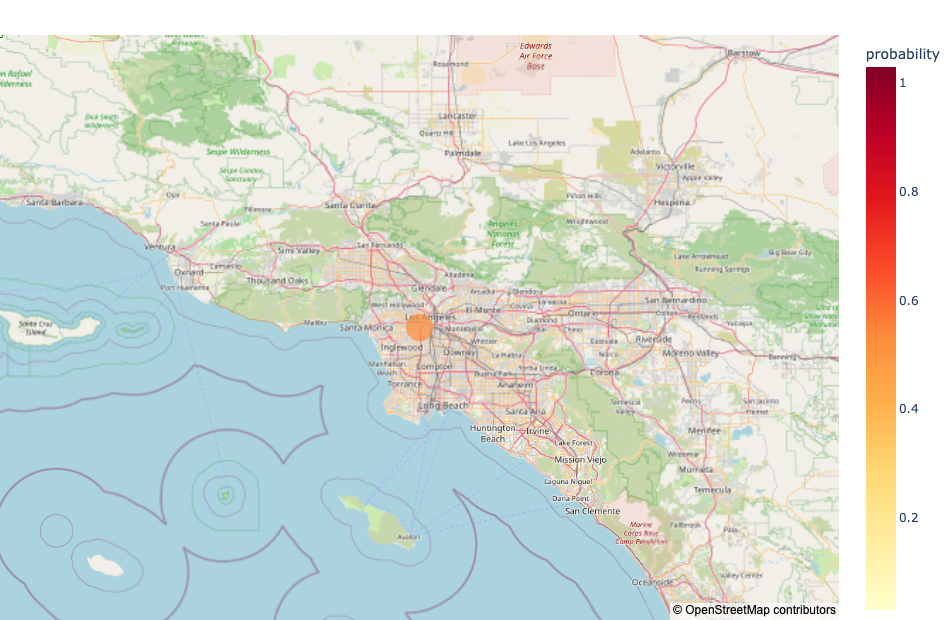

In [6]:
result_02 = run_question(2)


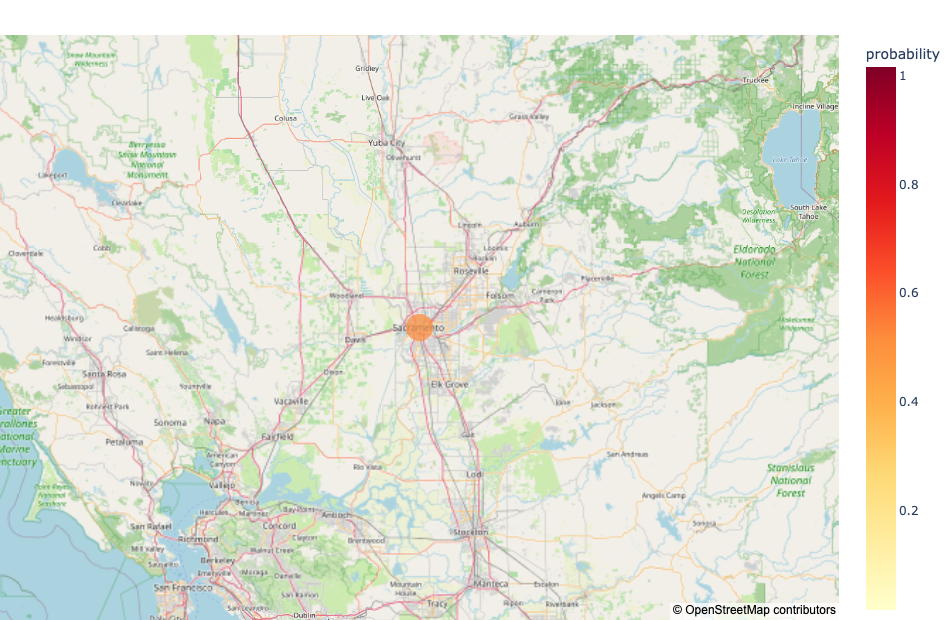

In [7]:
result_03 = run_question(3)


mean,min,max,std
0.2980,0.0825,0.5744,0.1842


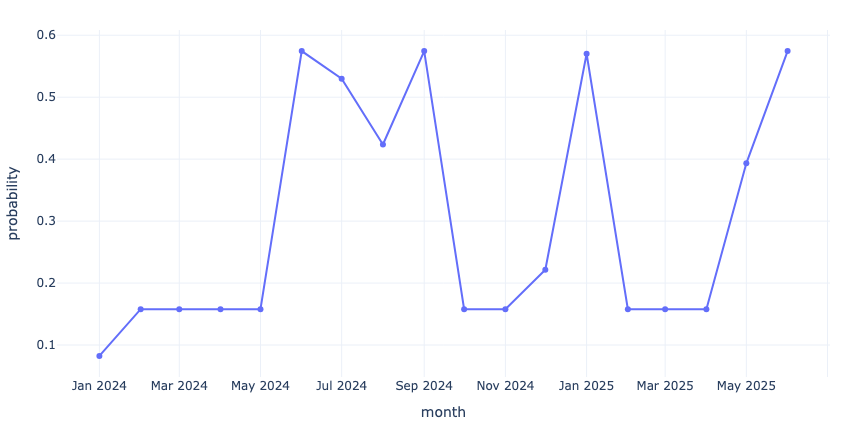

In [8]:
result_04 = run_question(4)


place,county_name,month,day7_tmax,day7_precip,probability
Los Angeles city,Los Angeles County,2025-06,28.5457,0.0383,0.3802
San Diego city,San Diego County,2025-06,30.0387,0.0680,0.5154
Fresno city,Fresno County,2025-06,31.1387,0.0023,0.9107


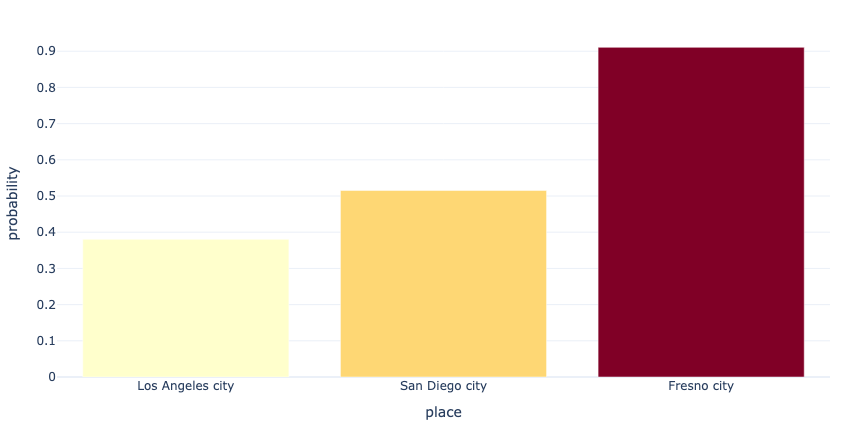

In [9]:
result_05 = run_question(5)


In [10]:
result_06 = run_question(6)


metric,field,value,baseline_mean,difference,z_score
day7_tmax,day7_tmax,34.6367,34.1176,0.5191,0.2353
day7_precip,day7_precip,0.0983,0.0151,0.0833,6.1384


field,value,baseline_mean,difference,z_score
day7_tmax,34.6367,34.1176,0.5191,0.2353
day7_precip,0.0983,0.0151,0.0833,6.1384


county_code,month,probability
06047,2023-09,0.8701
06099,2023-09,0.7864
06031,2023-09,0.7681
06039,2023-09,0.7592
06077,2023-09,0.6170
06085,2023-09,0.5949
06019,2023-09,0.5917
06015,2023-09,0.5025
06023,2023-09,0.5025
06069,2023-09,0.4809


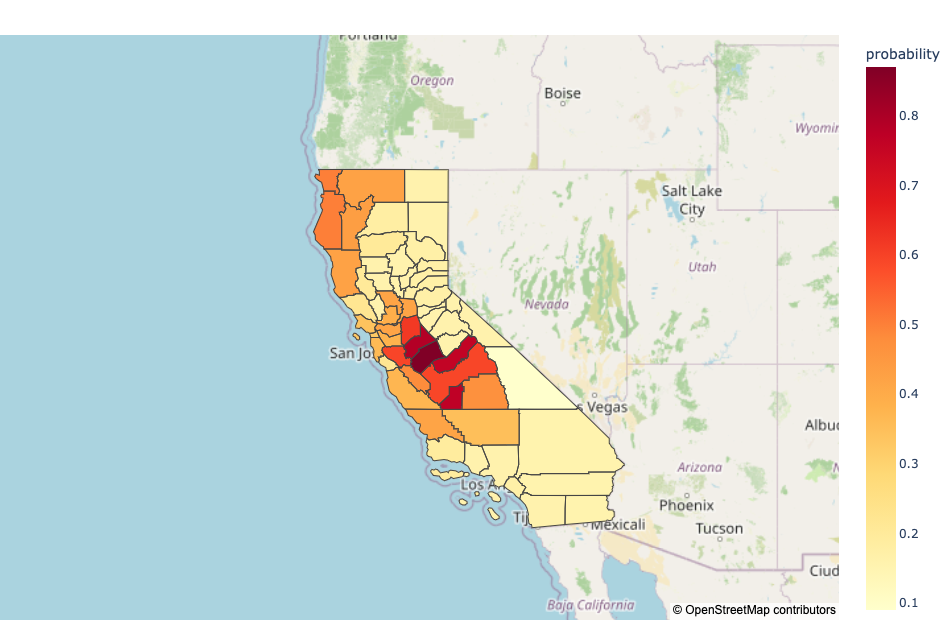

In [11]:
result_07 = run_question(7)


mean,min,max,std
0.4936,0.1376,0.9115,0.2800


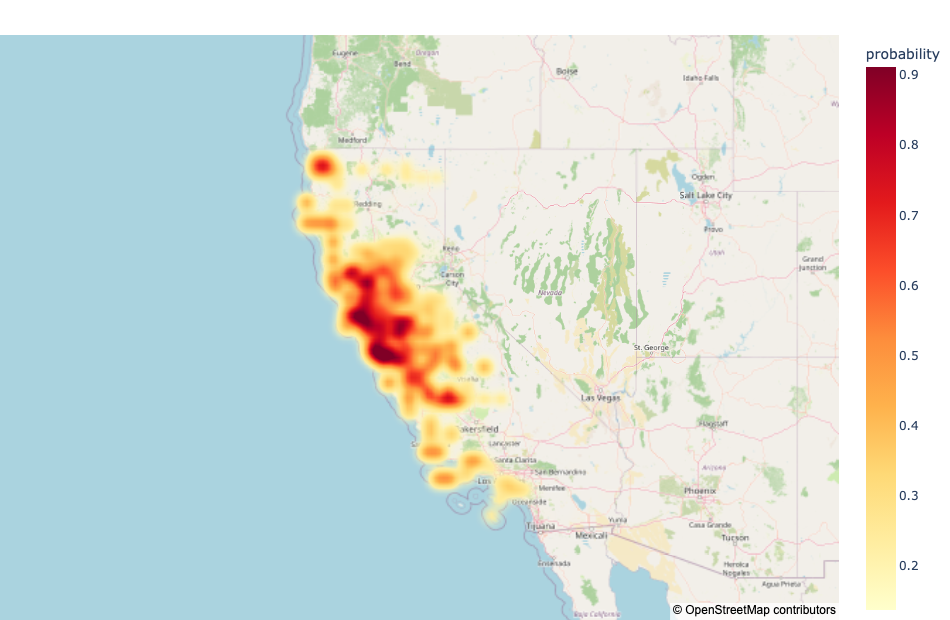

In [12]:
result_08 = run_question(8)


mean,min,max,std
0.6325,0.2620,0.9347,0.1537


county_name,latitude,longitude,probability
Santa Cruz County,36.8473,-122.0029,0.5852
Santa Cruz County,36.8473,-121.8853,0.5766
Monterey County,36.8473,-121.7676,0.5520
Monterey County,36.8473,-121.6500,0.5520
San Benito County,36.8473,-121.5323,0.5744
San Benito County,36.8473,-121.4147,0.5744
Santa Cruz County,36.9650,-122.1206,0.8992
Santa Cruz County,36.9650,-122.0029,0.5766
Santa Cruz County,36.9650,-121.8853,0.5474
Santa Cruz County,36.9650,-121.7676,0.5920


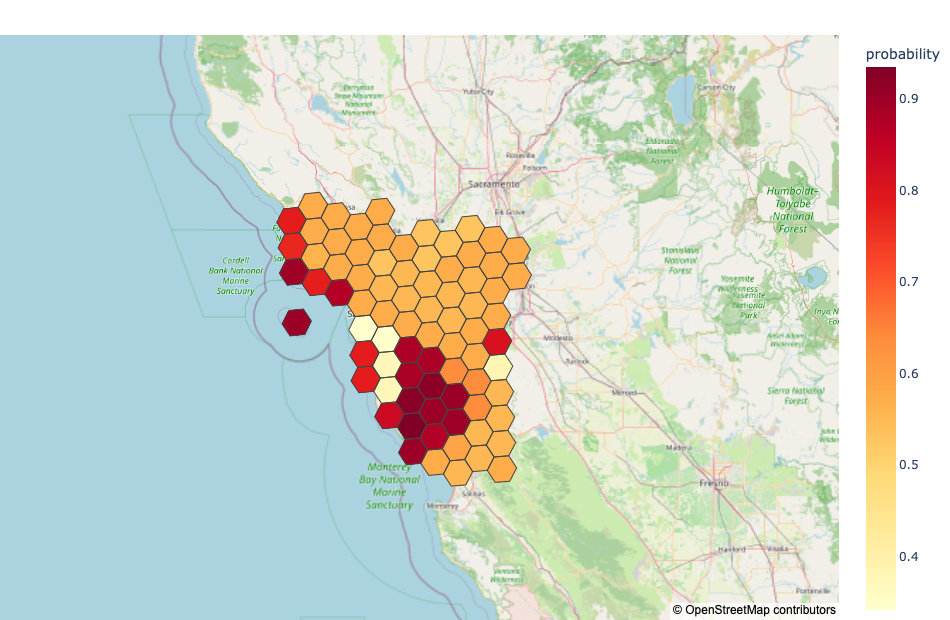

In [13]:
result_09 = run_question(9)


correlation,count
-0.2876,72


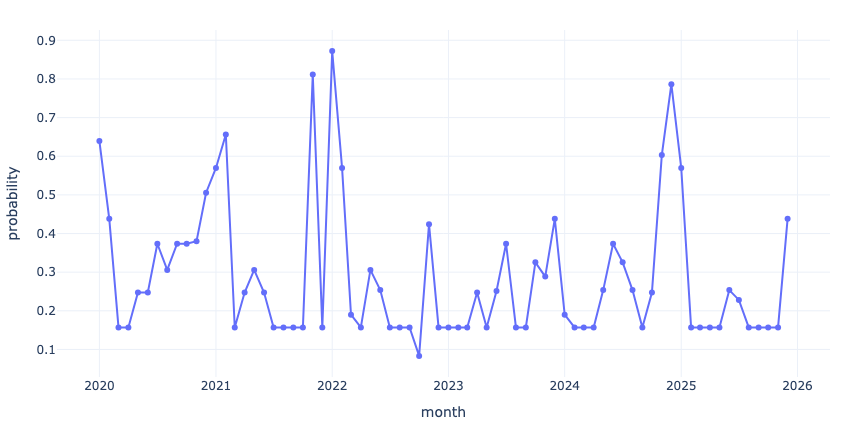

In [14]:
result_10 = run_question(10)
